<a href="https://colab.research.google.com/github/Rakesh-2211/Digital-line-coding-and-power-spectral-density/blob/main/Experiment_06_Digital_line_coding_and_power_spectral_density.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

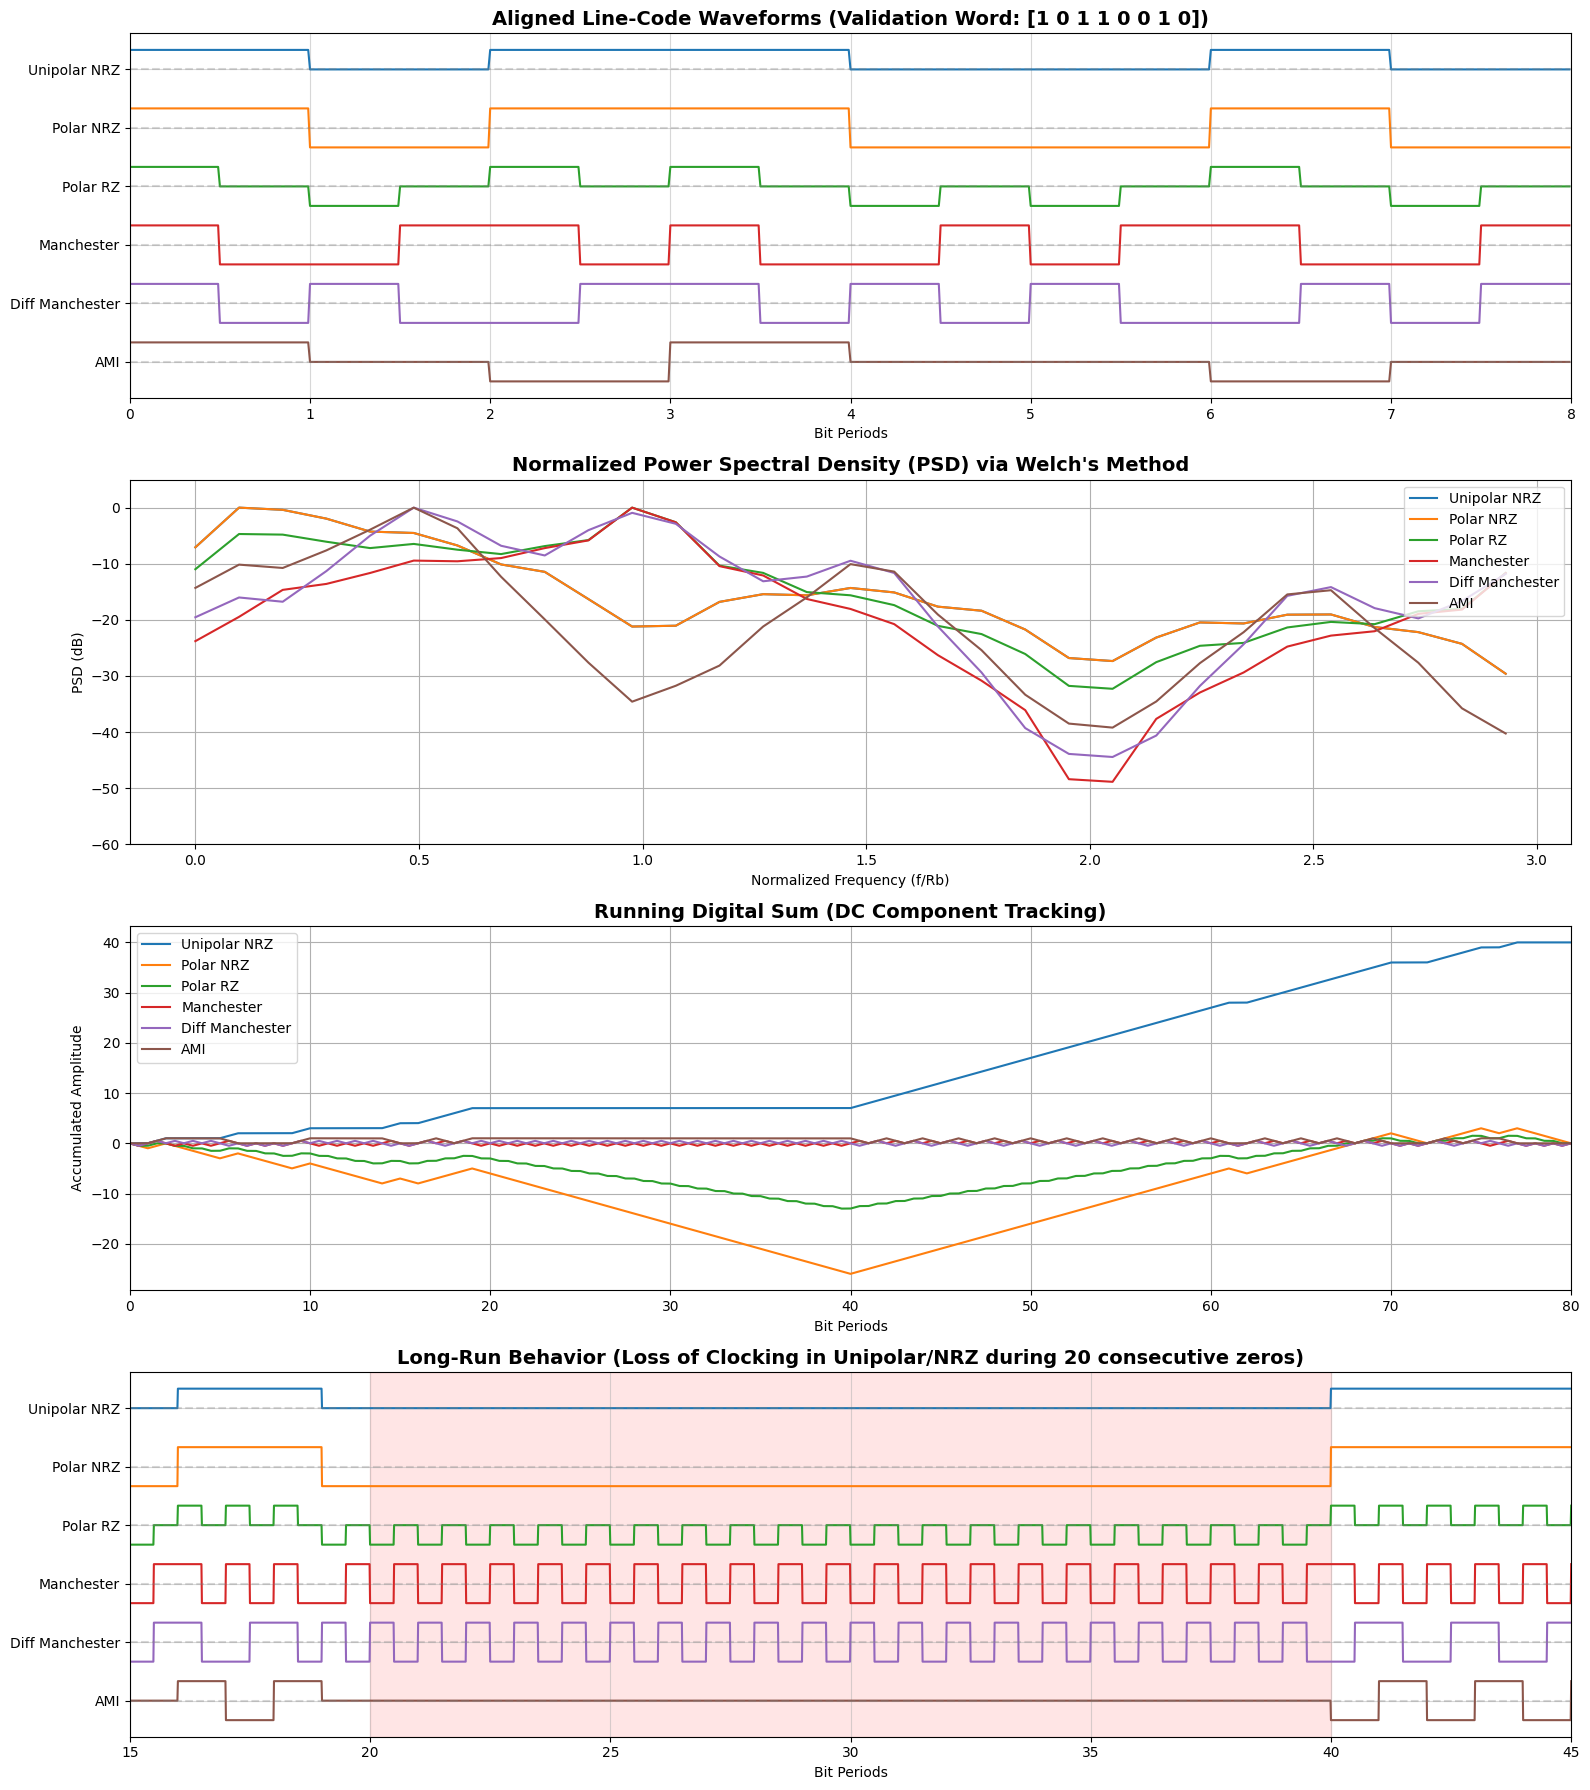

=== Observation and Theory Comparison ===

1. DC Component (Running Digital Sum):
- Theory: Unipolar and Polar NRZ suffer from DC wander. AMI, Manchester, and Diff Manchester have zero DC component.
- Observation: The RDS plot confirms that Unipolar/Polar NRZ drift continuously during long identical runs, while Manchester and AMI bound the RDS to zero.

2. Bandwidth (PSD):
- Theory: NRZ codes concentrate power at low frequencies. RZ and Manchester shift power to higher frequencies (wider bandwidth).
- Observation: The PSD plot shows Manchester/Diff Manchester peaking at f = 0.75 Rb with a null at DC. NRZ peaks at DC (f=0).

3. Self-Clocking Capability (Long-run behavior):
- Theory: NRZ and AMI lose clocking over long runs of zeros. Manchester guarantees a transition every bit.
- Observation: In the 'Long-Run Behavior' plot (red shaded area), Unipolar and AMI flatline during the 20 consecutive zeros, meaning clock synchronization would be lost. Manchester and Diff Manchester continue to

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==========================================
# 1. Line Coding Encoder Functions
# ==========================================
def encode_line_codes(bits, spb=100):
    """
    Generates waveforms for 6 line codes given a bit sequence.
    spb: samples per bit
    """
    t = np.linspace(0, len(bits), len(bits) * spb, endpoint=False)

    # Initialize signal arrays
    signals = {
        'Unipolar NRZ': np.zeros(len(t)),
        'Polar NRZ': np.zeros(len(t)),
        'Polar RZ': np.zeros(len(t)),
        'Manchester': np.zeros(len(t)),
        'Diff Manchester': np.zeros(len(t)),
        'AMI': np.zeros(len(t))
    }

    # State variables for differential and AMI
    last_level_diff = 1
    last_level_ami = -1

    for i, b in enumerate(bits):
        start, mid, end = i * spb, i * spb + spb // 2, (i + 1) * spb

        # 1. Unipolar NRZ (1 = +V, 0 = 0)
        signals['Unipolar NRZ'][start:end] = 1 if b == 1 else 0

        # 2. Polar NRZ (1 = +V, 0 = -V)
        signals['Polar NRZ'][start:end] = 1 if b == 1 else -1

        # 3. Polar RZ (1 = +V then 0, 0 = -V then 0)
        signals['Polar RZ'][start:mid] = 1 if b == 1 else -1
        signals['Polar RZ'][mid:end] = 0

        # 4. Manchester (IEEE: 1 = High-to-Low, 0 = Low-to-High)
        if b == 1:
            signals['Manchester'][start:mid] = 1
            signals['Manchester'][mid:end] = -1
        else:
            signals['Manchester'][start:mid] = -1
            signals['Manchester'][mid:end] = 1

        # 5. Differential Manchester
        # 0 = transition at start, 1 = no transition at start. Always transition in middle.
        if b == 0:
            level1 = -last_level_diff
        else:
            level1 = last_level_diff

        level2 = -level1
        signals['Diff Manchester'][start:mid] = level1
        signals['Diff Manchester'][mid:end] = level2
        last_level_diff = level2

        # 6. AMI (Alternate Mark Inversion: 0 = 0, 1 = alternating +/-)
        if b == 0:
            signals['AMI'][start:end] = 0
        else:
            last_level_ami = -last_level_ami
            signals['AMI'][start:end] = last_level_ami

    return t, signals

# ==========================================
# 2. Setup Bit Sequences
# ==========================================
# Mandatory validation: Specified eight-bit word to compare transitions
val_bits = np.array([1, 0, 1, 1, 0, 0, 1, 0])

# Long-run behavior test: Random bits + long runs of 0s and 1s + Random
np.random.seed(42)
long_run_bits = np.concatenate([
    np.random.randint(0, 2, 20),
    np.zeros(20, dtype=int), # Long run of 0s
    np.ones(20, dtype=int),  # Long run of 1s
    np.random.randint(0, 2, 20)
])

# Generate signals
spb = 100 # Samples per bit
t_val, sigs_val = encode_line_codes(val_bits, spb)
t_long, sigs_long = encode_line_codes(long_run_bits, spb)

# ==========================================
# 3. Visualizations
# ==========================================
fig = plt.figure(figsize=(16, 18))

# --- Plot 1: Aligned Line-Code Waveforms (Mandatory Validation) ---
ax1 = fig.add_subplot(4, 1, 1)
offset = 0
for name in sigs_val.keys():
    ax1.plot(t_val, sigs_val[name] + offset, label=name)
    ax1.axhline(offset, color='gray', linestyle='--', alpha=0.3)
    offset -= 3 # Stagger plots vertically

ax1.set_title(f'Aligned Line-Code Waveforms (Validation Word: {val_bits})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Bit Periods')
ax1.set_yticks(np.arange(0, -18, -3))
ax1.set_yticklabels(list(sigs_val.keys()))
ax1.grid(True, alpha=0.5)
ax1.set_xlim(0, len(val_bits))

# --- Plot 2: Normalized PSD in dB (Using Welch's Method) ---
ax2 = fig.add_subplot(4, 1, 2)
for name, sig in sigs_long.items():
    # Welch's method estimation
    f, Pxx = welch(sig, fs=spb, nperseg=1024, scaling='density')

    # Normalize PSD to dB
    Pxx_norm_dB = 10 * np.log10(Pxx / np.max(Pxx))

    # Plot only the relevant frequency band (up to 3x bit rate)
    valid_idx = f <= 3
    ax2.plot(f[valid_idx], Pxx_norm_dB[valid_idx], label=name)

ax2.set_title('Normalized Power Spectral Density (PSD) via Welch\'s Method', fontsize=14, fontweight='bold')
ax2.set_xlabel('Normalized Frequency (f/Rb)')
ax2.set_ylabel('PSD (dB)')
ax2.legend(loc='upper right')
ax2.grid(True)
ax2.set_ylim(-60, 5)

# --- Plot 3: Running Digital Sum (RDS) ---
ax3 = fig.add_subplot(4, 1, 3)
for name, sig in sigs_long.items():
    # Integrate over the signal and normalize by samples per bit to get discrete RDS
    rds = np.cumsum(sig) / spb
    ax3.plot(t_long, rds, label=name)

ax3.set_title('Running Digital Sum (DC Component Tracking)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Bit Periods')
ax3.set_ylabel('Accumulated Amplitude')
ax3.legend(loc='upper left')
ax3.grid(True)
ax3.set_xlim(0, len(long_run_bits))

# --- Plot 4: Long-Run Behavior ---
# Show a slice of the long-run signal focusing on the transition into 20 zeros
ax4 = fig.add_subplot(4, 1, 4)
focus_start, focus_end = 15, 45 # Zoom in on the transition to the 20-zero block
t_zoom = t_long[(t_long >= focus_start) & (t_long <= focus_end)]

offset = 0
for name in sigs_long.keys():
    sig_zoom = sigs_long[name][(t_long >= focus_start) & (t_long <= focus_end)]
    ax4.plot(t_zoom, sig_zoom + offset, label=name)
    ax4.axhline(offset, color='gray', linestyle='--', alpha=0.3)
    offset -= 3

ax4.set_title('Long-Run Behavior (Loss of Clocking in Unipolar/NRZ during 20 consecutive zeros)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Bit Periods')
ax4.set_yticks(np.arange(0, -18, -3))
ax4.set_yticklabels(list(sigs_long.keys()))
ax4.grid(True, alpha=0.5)
ax4.set_xlim(focus_start, focus_end)
# Highlight the zero block
ax4.axvspan(20, 40, color='red', alpha=0.1, label='Long run of 0s')

plt.tight_layout()
plt.show()

# ==========================================
# 4. Observation and Interpretation Output
# ==========================================
def print_theoretical_comparison():
    print("=== Observation and Theory Comparison ===\n")
    print("1. DC Component (Running Digital Sum):")
    print("- Theory: Unipolar and Polar NRZ suffer from DC wander. AMI, Manchester, and Diff Manchester have zero DC component.")
    print("- Observation: The RDS plot confirms that Unipolar/Polar NRZ drift continuously during long identical runs, while Manchester and AMI bound the RDS to zero.\n")

    print("2. Bandwidth (PSD):")
    print("- Theory: NRZ codes concentrate power at low frequencies. RZ and Manchester shift power to higher frequencies (wider bandwidth).")
    print("- Observation: The PSD plot shows Manchester/Diff Manchester peaking at f = 0.75 Rb with a null at DC. NRZ peaks at DC (f=0).\n")

    print("3. Self-Clocking Capability (Long-run behavior):")
    print("- Theory: NRZ and AMI lose clocking over long runs of zeros. Manchester guarantees a transition every bit.")
    print("- Observation: In the 'Long-Run Behavior' plot (red shaded area), Unipolar and AMI flatline during the 20 consecutive zeros, meaning clock synchronization would be lost. Manchester and Diff Manchester continue to toggle, preserving self-clocking.")

print_theoretical_comparison()